# Italy Population By Province

## Table of Contents

1. Project Overview
2. Data Import
3. Dataset Overview
4. Data Cleaning
5. Feature Engineering
6. Property Features Analysis
7. Correlation Analysis
8. Text Analysis
9. Outlier Analysis
10. Key Insights


## 1. Project Overview

This project analyzes population distribution in Italy over multiple years with a focus on gender structure and regional differences.
The goal is to explore how the population changes over time, identify demographic patterns, and highlight regions with the highest and lowest population levels.

The dataset contains population statistics by region, year, and sex, including the total population as well as the number of women and men.

### 1.1. Objectives

The main objectives of the analysis are:

- Examine overall population trends over time
- Compare population distribution between women and men
- Analyze population share by gender
- Identify regions with the highest and lowest population
- Explore population trends for the largest regions
- Measure population growth or decline over time

### 1.2. Data Processing

The analysis includes several preprocessing steps:
- Loading multiple CSV files containing yearly population data
- Extracting the year from file names
- Merging all datasets into a single dataframe
- Cleaning and renaming columns
- Creating aggregated datasets for national and regional analysis

### 1.3. Key Metrics Created

Several additional indicators were calculated to support the analysis:
- Total population per year
- Population growth rate
- Female and male population share (%)
- Sex ratio (number of men per 100 women)
- Regional population share

### 1.4. Visualizations

The project includes multiple visualizations to illustrate demographic patterns:
- Population distribution histogram
- Yearly population comparison between women and men
- Gender population share over time
- Overall population trend
- Regional population comparison
- Population trends for the largest regions

### 1.5. Tools Used

- Python
- Pandas for data processing
- Matplotlib and Seaborn for data visualization
- NumPy for numerical operations

## 2. Data Import

In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter

files = glob.glob(r'data\*.csv')
dataframes = []

for file in files:
    df = pd.read_csv(file)
    df['Year'] = os.path.splitext(os.path.basename(file))[0]
    dataframes.append(df)

population_raw_df = pd.concat(dataframes)

## 3. Dataset overview

In [3]:
population_raw_df.info()

<class 'pandas.DataFrame'>
Index: 1070 entries, 0 to 106
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   REF_AREA    1070 non-null   str  
 1   Territorio  1070 non-null   str  
 2   F           1070 non-null   int64
 3   M           1070 non-null   int64
 4   OBS_VALUE   1070 non-null   int64
 5   Year        1070 non-null   str  
dtypes: int64(3), str(3)
memory usage: 58.5 KB


In [4]:
population_raw_df.isna().sum()

REF_AREA      0
Territorio    0
F             0
M             0
OBS_VALUE     0
Year          0
dtype: int64

In [5]:
print(f'Number of rows {len(population_raw_df)}')

Number of rows 1070


In [6]:
print(f"Unique reqions: {population_raw_df['Territorio'].nunique()}")

Unique reqions: 107


# 4. Data cleaning

In [7]:
population_raw_df['Year'] = population_raw_df['Year'].astype(int)

population_raw_df.rename(
    columns={
        'OBS_VALUE':'Total', 
        'Territorio':'Region'
        }, 
        inplace = True)

population_2023_df = population_raw_df[population_raw_df['Year'] == 2023].reset_index()


## 5. Feature Engineering

In [8]:
population_yearly_df = population_raw_df.groupby('Year').agg(
        F = ('F', 'sum'),
        M = ('M', 'sum'),
        Total = ('Total', 'sum')
        ).reset_index()

population_yearly_df['Year'] = pd.to_datetime(population_yearly_df['Year'], format='%Y').dt.year
population_yearly_df['Pct_change'] = population_yearly_df['Total'].pct_change().fillna(0) * 100
population_yearly_df['F%'] = population_yearly_df['F'] / population_yearly_df['Total'] * 100
population_yearly_df['M%'] = population_yearly_df['M'] / population_yearly_df['Total'] * 100
population_yearly_df['Sex_ratio'] = population_yearly_df['M'] / population_yearly_df['F'] * 100


# 6. Population distribution

## 6.1. Population distribution by region

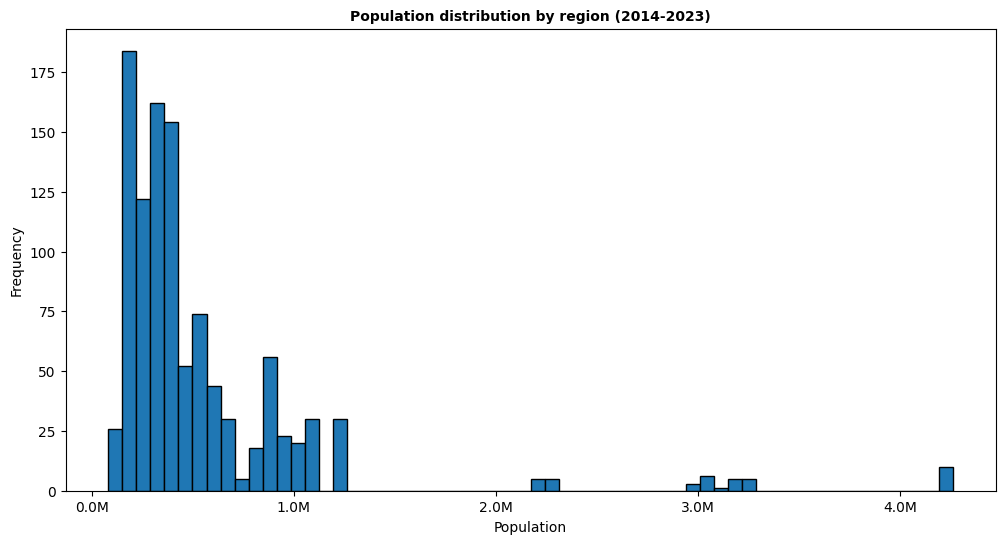

In [9]:
plt.figure(figsize=(12,6))

plt.hist(
    population_raw_df['Total'], 
    bins=60,
    edgecolor = 'black')

formatter = FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)

plt.title(
    "Population distribution by region (2014-2023)",
    fontsize=10, 
    fontweight='bold')
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.show()

Populacja Włoch jest dużej mierze rozporoszona i skupia się głównie w mniejszych i średnich miastach

## 6.2. Population by sex overtime

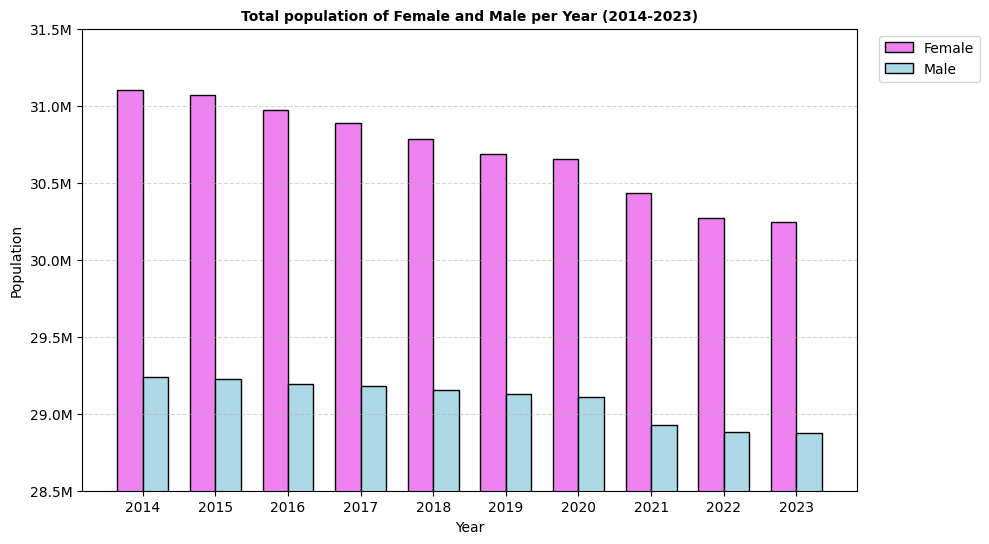

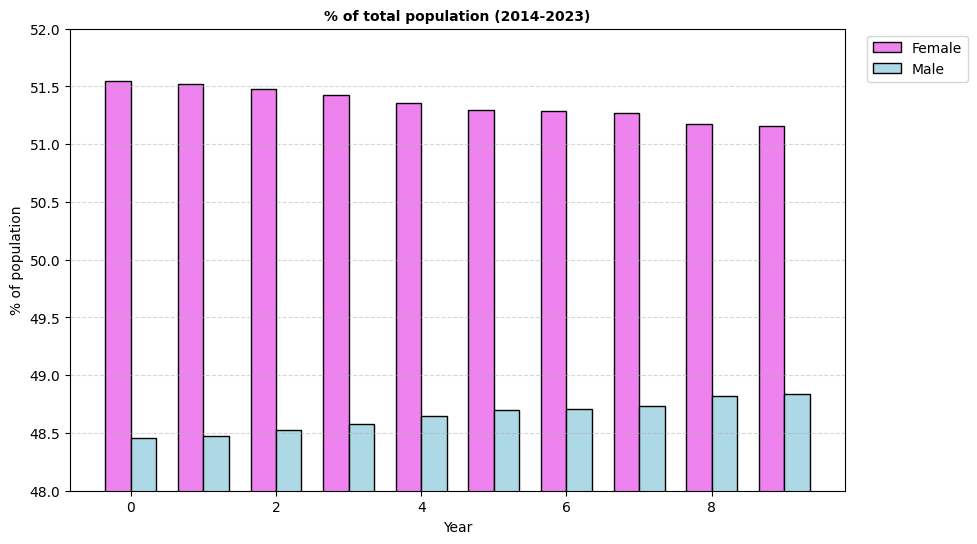

In [19]:
plt.figure(figsize=(10,6))

labels = population_yearly_df['Year']
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, population_yearly_df['F'], width, label='Female', color='violet', edgecolor = 'black')
plt.bar(x + width/2, population_yearly_df['M'], width, label='Male', color='lightblue', edgecolor = 'black')

plt.xticks(x, population_yearly_df['Year'])

plt.title(
    'Total population of Female and Male per Year (2014-2023)',
    fontsize=10, 
    fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

formatter = FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylim(28_500_000, 31_500_000)

plt.show()

x = np.arange(len(population_yearly_df['Year']))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, population_yearly_df['F%'], width, label='Female', color = 'violet', edgecolor = 'black')
plt.bar(x + width/2, population_yearly_df['M%'], width, label='Male', color = 'lightblue', edgecolor = 'black')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title(
    '% of total population (2014-2023)',
    fontsize=10, 
    fontweight='bold')
plt.ylabel('% of population')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(48, 52)

plt.show()

Udział kobiet w ogólnej populacji jest większy. 
Natomiast obserwuje się niewielką maskulinizację społeczeństwa.

## 6.3. Sex ratio (men per 100 women)

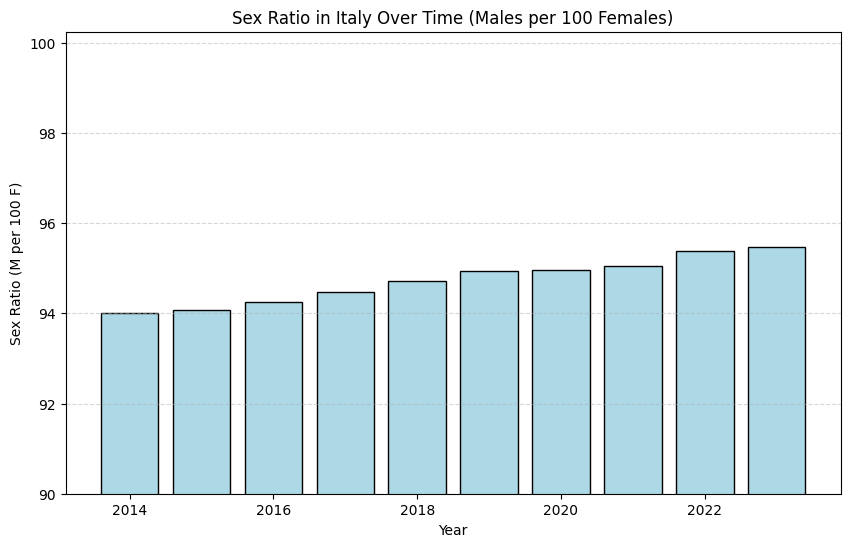

In [20]:
plt.figure(figsize=(10,6))
plt.bar(population_yearly_df['Year'], population_yearly_df['Sex_ratio'], color='lightblue', edgecolor = 'black')
plt.title('Sex Ratio in Italy Over Time (Males per 100 Females)')
plt.xlabel('Year')
plt.ylabel('Sex Ratio (M per 100 F)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(90)
plt.show()

Na jedną kobietę przypada obecnie 95.47 co od początku wzrosło o 1.5.

# 7. Population trends

## 7.1. Overall population trend overtime 

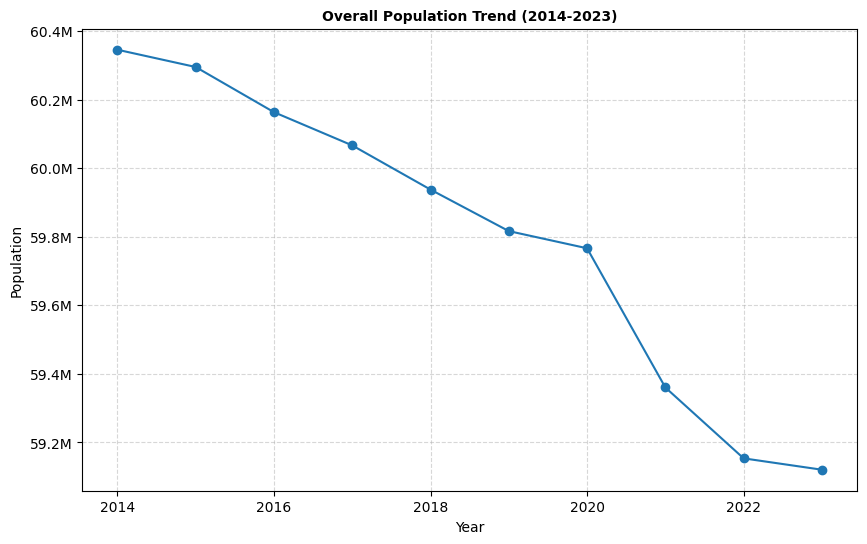

In [12]:
plt.figure(figsize=(10,6))

plt.plot(
    population_yearly_df['Year'],
    population_yearly_df['Total'],
    marker = 'o')
formatter = FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "Overall Population Trend (2014-2023)",
    fontsize=10, 
    fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Population")

plt.grid(axis='both', linestyle='--', alpha=0.5)

plt.show()

## 7.2. Growth and decline rates

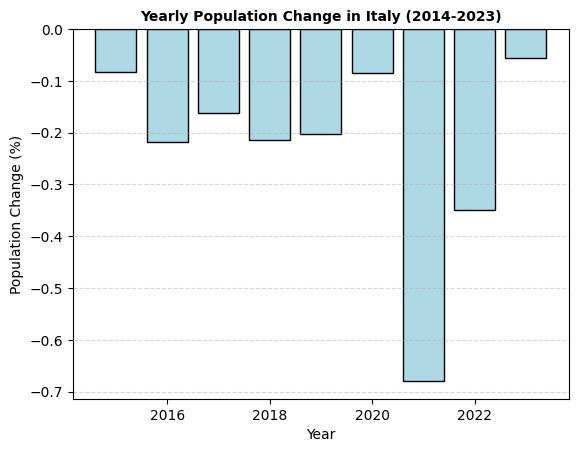

In [23]:
population_change_df = population_yearly_df[population_yearly_df['Year'] > 2014]

plt.bar(
    population_change_df['Year'],
    population_change_df['Pct_change'],
    color = 'lightblue',
    edgecolor = 'black'
)

plt.title(
    'Yearly Population Change in Italy (2014-2023)', 
    fontsize=10, 
    fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Population Change (%)')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 7.3. Years with maximum and minimum population change

In [14]:
min = population_change_df[population_change_df['Pct_change'] == population_change_df['Pct_change'].min()][['Year','Pct_change']]
max = population_change_df[population_change_df['Pct_change'] == population_change_df['Pct_change'].max()][['Year','Pct_change']]

population_change_extermes_df = pd.concat([max, min])
population_change_extermes_df.index = ['Lowest change population','Highest change population']
population_change_extermes_df

,Year,Pct_change
Lowest change population,2023,-0.056061
Highest change population,2021,-0.679678


# 8. Regional analysis (2023)

### 8.1. Population per region

In [15]:
region_sex_share_df = population_2023_df[['Region', 'F', 'M', 'Total']]
region_sex_share_df['F%'] = region_sex_share_df['F'] / region_sex_share_df['Total'] * 100
region_sex_share_df['M%'] = region_sex_share_df['M'] / region_sex_share_df['Total'] * 100
region_sex_share_df['Sex_ratio'] = region_sex_share_df['M'] / region_sex_share_df['F'] * 100

region_sex_share_df.sort_values('Total', ascending=False)

,Region,F,M,Total,F%,M%,Sex_ratio
66,Roma,2193222,2033837,4227059,51.885294,48.114706,92.732838
16,Milano,1655817,1572189,3228006,51.295351,48.704649,94.949442
77,Napoli,1530744,1449594,2980338,51.361423,48.638577,94.698656
0,Torino,1134747,1069885,2204632,51.471039,48.528961,94.284012
18,Brescia,634124,623202,1257326,50.434334,49.565666,98.277624
...,...,...,...,...,...,...,...
92,Vibo Valentia,76093,74616,150709,50.490017,49.509983,98.058954
65,Rieti,75366,75091,150457,50.091388,49.908612,99.635114
105,Oristano,76337,73988,150325,50.781307,49.218693,96.922855
35,Gorizia,69890,68144,138034,50.632453,49.367547,97.501789


### 8.2. Regions with maximum and minimum population

In [16]:
region_population_extremes_2023 = population_2023_df[
    (population_2023_df['Total'] == population_2023_df['Total'].max()) | 
    (population_2023_df['Total'] == population_2023_df['Total'].min())][['Region', 'Total']]
region_population_extremes_2023.rename(columns={'Total':'Total_Population'}, inplace=True)
region_population_extremes_2023.index = ['Region with highest population', 'Region with lowest population']

region_population_extremes_all_time = population_raw_df[
    (population_raw_df['Total'] == population_raw_df['Total'].max()) |
    (population_raw_df['Total'] == population_raw_df['Total'].min())
][['Year','Region','Total']]

region_population_extremes_all_time.rename(columns={'Total':'Total_Population'}, inplace=True)
region_population_extremes_all_time.index = ['Region with highest population overall', 'Region with lowest population overall']

display(region_population_extremes_2023)
display(region_population_extremes_all_time)


,Region,Total_Population
Region with highest population,Roma,4227059
Region with lowest population,Isernia,79912


,Year,Region,Total_Population
Region with highest population overall,2019,Roma,4263542
Region with lowest population overall,2023,Isernia,79912


### 8.3. Top 5 regions by population share

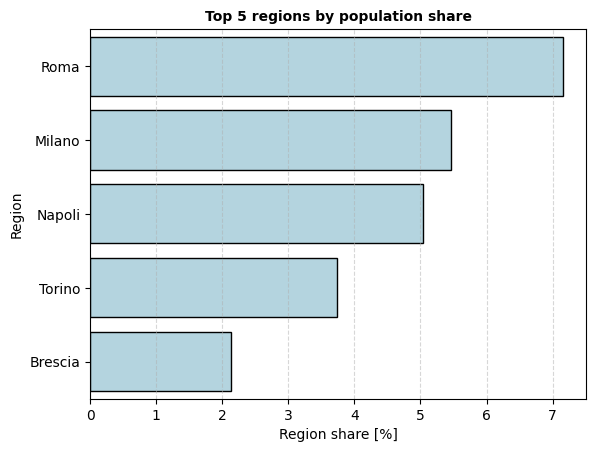

In [24]:
region_population_share_df = population_2023_df[['Region','Total']]
region_population_share_df['Region_share_%'] = region_population_share_df['Total'] / region_population_share_df['Total'].sum() * 100
top5_regions_df = region_population_share_df.nlargest(5, 'Total')

sns.barplot(
    data=top5_regions_df,
    x='Region_share_%',
    y='Region',
    color = 'lightblue',
    edgecolor = 'black'
)

plt.xlabel('Region share [%]')
plt.title("Top 5 regions by population share",
    fontsize=10, 
    fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## 9. Regional trends

## 9.1. Trends for 5 top regions

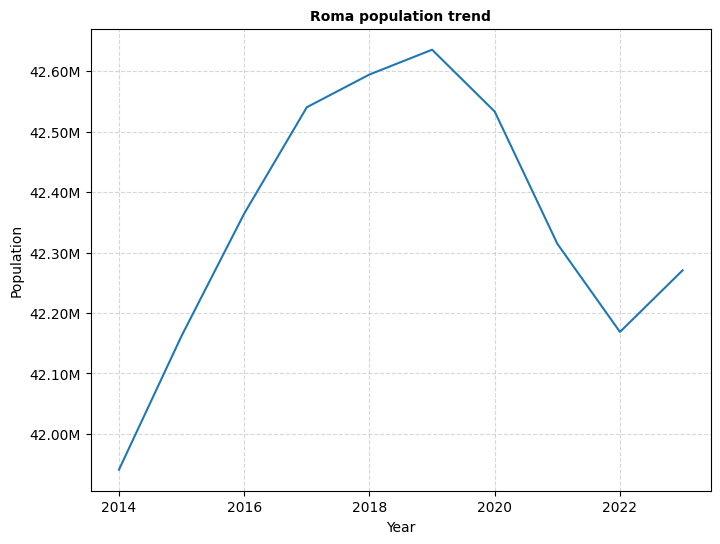

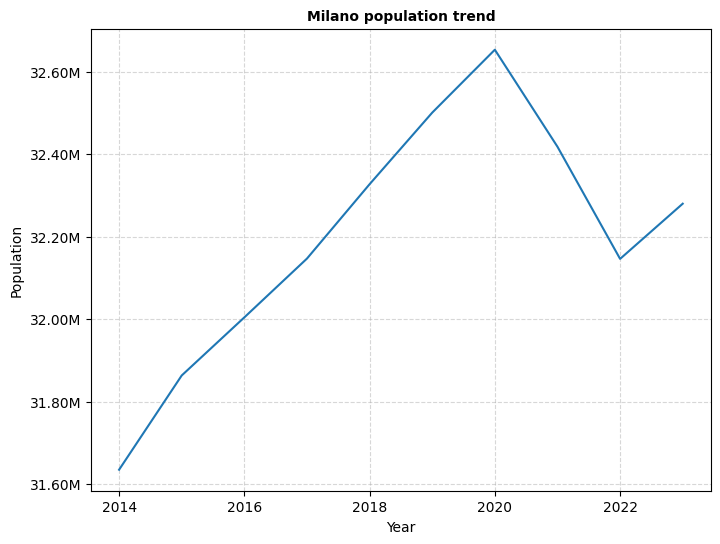

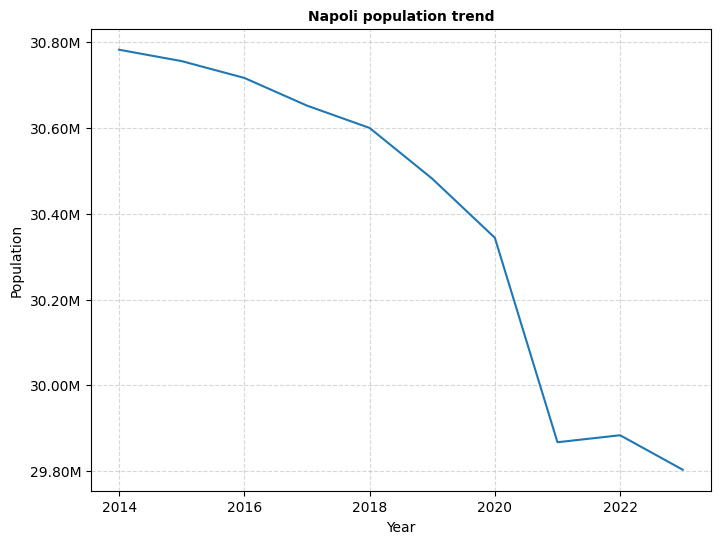

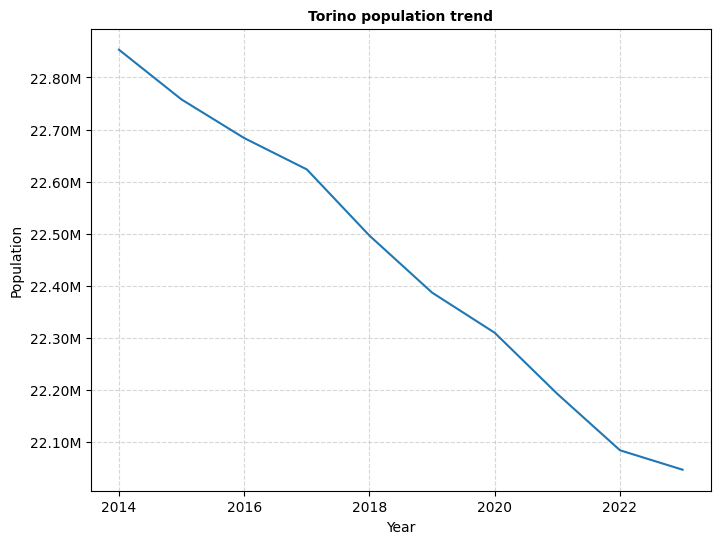

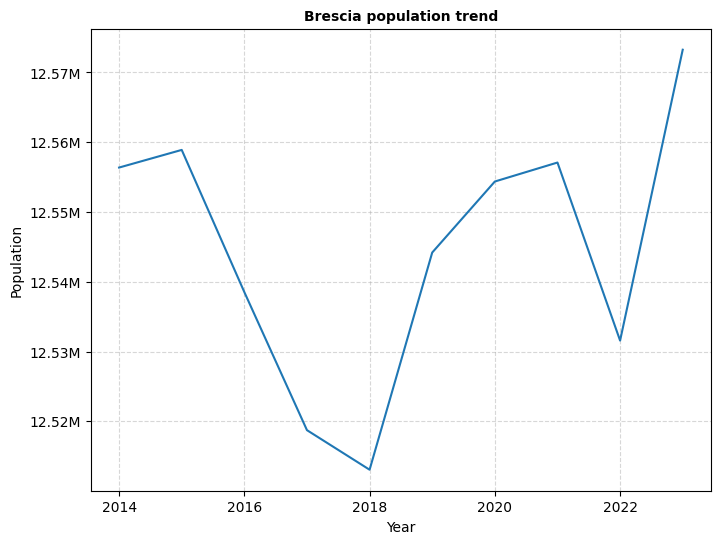

In [18]:
trend = population_raw_df[['Year','Region','Total']]

for region in top5_regions_df['Region']:

    data = trend[trend['Region'] == region]
    plt.figure(figsize=(8,6))
    plt.plot(
        data['Year'],
        data['Total']
    )

    formatter = FuncFormatter(lambda x, pos: f'{x/100_000:.2f}M')
    plt.gca().yaxis.set_major_formatter(formatter)

    plt.ylabel('Population')
    plt.xlabel('Year')

    plt.title(
        f'{region} population trend',
        fontsize=10, 
        fontweight='bold')
    
    plt.grid(axis='both', linestyle='--', alpha=0.5)

plt.show()